In [51]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', 60)
pd.set_option('display.width', 200)

In [52]:
#SWAN Baseline Dataset: ICPSR 28762
data = pd.read_csv("./data/28762-0001-Data.csv")

C:\Users\Sharanya Nagar\AppData\Local\Temp\ipykernel_17692\1680451954.py:2: DtypeWarning: Columns (32,34,36,38,52,54,56,58,60,62,64,66,68,70,72,74,76,78,80,82,84,119,159,162,168,174,180,192,204,210,215,216,218,220,222,223,261,275,276,277,278,279,280,303,311,397,403,405,407,409,413,486) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv("./data/28762-0001-Data.csv")


In [53]:
df = pd.DataFrame(data)
df.head()

,SWANID,VISIT,INTDAY0,AGE0,PREGNAN0,PREVBLO0,ALCHL240,EATDRIN0,STRTPER0,BLDRWAT0,BLDDRAW0,ANTICOA0,ACOAYS0,HEART0,HARTYS0,ULCER0,ULCRYS0,CHOLEST0,CHOLYS0,BP0,BPYS0,THYROID0,THYRYS0,INSULIN0,INSUYS0,NERVOUS0,NERVYS0,STEROID0,STERYS0,INHALER0,...,CHOLRES0,FACRESU0,FIBRESU0,GLUCRES0,HDLRESU0,INSURES0,LDLRESU0,LPARESU0,PAIRESU0,TPARESU0,TRIGRES0,LPA1RES0,APOARES0,APOBRES0,CRPRESU0,FLAGCO20,FLAGSER0,SPSCDAY0,SPSCTIM0,SPSCMOD0,HPSCDAY0,HPSCTIM0,HPSCMOD0,SPBMDT0,HPBMDT0,BMDFLG0,STATUS0,LMPDAY0,OCCUP0,RACE
0,10005,0,0,48.0,No,NaN,No,No,Yes,"Yes, as per protocol",Yes,No,NaN,No,NaN,No,NaN,No,NaN,No,NaN,No,NaN,No,NaN,Yes,Yes,No,NaN,No,...,137.0,151.0,298.0,102.0,40.0,7.2,73.0,22.0,38.0,8.5,122.0,46.0,114.0,78.0,3.1,No,No,NaN,.,NaN,NaN,.,NaN,NaN,NaN,NaN,NaN,NaN,Hairdressers & cosmetologists,Hispanic
1,10046,0,0,52.0,No,NaN,No,No,Yes,"Yes, as per protocol",Yes,No,NaN,No,NaN,No,NaN,No,NaN,No,NaN,No,NaN,No,NaN,No,NaN,No,NaN,No,...,221.0,159.0,265.0,100.0,57.0,13.7,136.0,8.0,46.1,8.2,138.0,46.0,191.0,142.0,1.6,No,No,0.0,0:09:03,2000 machine,0.0,0:08:53,5: 2000 machine,1.1163,0.9280,NaN,Early Peri,-35.0,General office clerks,Chinese/Chinese American
2,10056,0,0,51.0,No,No,Yes,No,Yes,"Yes, as per protocol",Yes,No,NaN,No,NaN,No,NaN,No,NaN,No,NaN,No,NaN,No,NaN,No,NaN,No,NaN,No,...,176.0,104.0,199.0,88.0,76.0,4.3,85.0,34.0,4.6,4.4,75.0,68.0,169.0,81.0,0.3,No,No,75.0,0:15:07,4500 machine,75.0,0:15:17,11: 4500 machine,0.8954,0.8547,NaN,Pre-menopausal,-57.0,NaN,Caucasian/White Non-Hispanic
3,10092,0,0,45.0,No,NaN,Yes,No,Yes,"Yes, as per protocol",Yes,No,NaN,No,NaN,No,NaN,No,NaN,No,NaN,No,NaN,No,NaN,No,NaN,No,NaN,No,...,197.0,137.0,464.0,114.0,44.0,26.8,136.0,6.0,51.2,14.4,85.0,42.0,129.0,125.0,24.1,No,No,0.0,0:18:29,2000 machine,0.0,0:18:13,5: 2000 machine,1.0471,0.8158,NaN,Early Peri,-59.0,"Purchasing agents & buyers, n.e.c.",Caucasian/White Non-Hispanic
4,10126,0,0,48.0,No,NaN,No,No,Yes,"Yes, as per protocol",Yes,No,NaN,No,NaN,No,NaN,No,NaN,No,NaN,No,NaN,No,NaN,No,NaN,No,NaN,No,...,207.0,84.0,340.0,93.0,45.0,11.3,151.0,58.0,14.2,4.3,57.0,43.0,130.0,129.0,2.8,No,No,NaN,.,NaN,NaN,.,NaN,NaN,NaN,NaN,Early Peri,-49.0,Registered nurses,Black/African American


In [54]:
#shape
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

print("Unique ids:", df["SWANID"].nunique())
print("Duplicated ids:", df["SWANID"].duplicated().sum())
print("Missing ids:", df["SWANID"].isnull().sum())

Rows: 3302
Columns: 741
Unique ids: 3302
Duplicated ids: 0
Missing ids: 0


In [55]:
feature_groups = {
    'vasomotor': ['HOTFLAS0', 'NITESWE0', 'COLDSWE0', 'FLASHPH0', 'FLASHEB0', 'FLASHEM0'],
    'psychological': ['FEELBLU0', 'IRRITAB0', 'NRVOUS0', 'FORGET0', 'MOODCHG0', 'FEARFULA0'],
    'somatic_physical': ['STIFF0', 'HDACHE0', 'VAGINDR0', 'HARTRAC0', 'DIZZY0', 'LEAKURI0'],
    'sleep': ['TRBLSLE0', 'WAKEUP0', 'WAKEARL0'],
    'hormonal': ['FSH0', 'E2AVE0', 'T0', 'TSH0', 'SHBG0', 'DHAS0'],
    'anthropometric_vitals': ['BMI0', 'WAIST0', 'HIP0', 'PULSE0', 'SYSBP10', 'DIABP10'],
    'cesd_depression': ['BOTHER0', 'APPETIT0', 'BLUES0', 'GOOD0', 'KEEPMIN0', 'DEPRESS0',
                         'EFFORT0', 'HOPEFUL0', 'FAILURE0', 'FEARFUL0', 'RESTLES0', 'HAPPY0',
                         'TALKLES0', 'LONELY0'],
    'demographic_lifestyle': ['AGE0', 'RACE', 'SMOKERE0', 'PHY_ACT' if 'PHY_ACT' in df.columns else 'SPORTS0'],
    'validation_only': ['STATUS0'],   # held out from clustering, used post-hoc only
}

In [56]:
for col in df.columns:
    print(col)

SWANID
VISIT
INTDAY0
AGE0
PREGNAN0
PREVBLO0
ALCHL240
EATDRIN0
STRTPER0
BLDRWAT0
BLDDRAW0
ANTICOA0
ACOAYS0
HEART0
HARTYS0
ULCER0
ULCRYS0
CHOLEST0
CHOLYS0
BP0
BPYS0
THYROID0
THYRYS0
INSULIN0
INSUYS0
NERVOUS0
NERVYS0
STEROID0
STERYS0
INHALER0
INHAYS0
HORMCRE0
HCRMYS0
HORMPIL0
HORMYS0
ESTRPTC0
ESTRYS0
BCP0
BCPYS0
OTHMED0
OTHRYS0
PAIN0
PAINYS0
SLEEP0
SLEPYS0
BOWEL0
BOWLYS0
HEARTBR0
HBRNYS0
OTHOTC0
OTCYS0
INSUEVE0
INSUEVM0
THYREVE0
THYREVM0
CORTEVE0
CORTEVM0
COAGEVE0
COAGEVM0
BARBEVE0
BARBEVM0
DIUREVE0
DIUREVM0
CONVEVE0
CONVEVM0
LITHEVE0
LITHEVM0
AMPHEVE0
AMPHEVM0
PREMEVE0
PREMEVM0
PTCHEVE0
PTCHEVM0
COMBEVE0
COMBEVM0
PROVEVE0
PROVEVM0
TAMOEVE0
TAMOEVM0
DESEVER0
DESEVMO0
DEPOEVE0
DEPOEVM0
FERTEVE0
FERTEVM0
BCEVER0
BCEVMO0
BCREAS0
STROKE0
STROKMD0
HBCHOLE0
HBCHOMD0
MIGRAIN0
MIGRAMD0
GALLSTO0
GALLSMD0
OSTEOAR0
OSTEOMD0
OATHYRO0
OATHYMD0
UATHYRO0
UATHYMD0
HBCALCI0
HBCALMD0
ANEMIA0
ANEMIMD0
LIVER0
LIVERMD0
EPILEPS0
EPILEMD0
PHLEBIT0
PHLEBMD0
ANOREXI0
ANOREMD0
BULIMIA0
BULIMMD0
TUBERCU0
TUBERMD0
A

In [57]:
null = df.isnull().mean().sort_values(ascending=False)*100

print(">90% missing values: ",(null > 90).sum())
print(">50% missing values: ",(null > 50).sum())
print("0% missing values: ",(null == 00).sum())

missing_more_than_90 = null.index.tolist()[0:91]


>90% missing values:  91
>50% missing values:  177
0% missing values:  116


In [58]:
df = df.drop(columns=missing_more_than_90)
df.shape

(3302, 650)

In [62]:
null = df.isnull().mean().sort_values(ascending=False)*100
print(">90% missing values: ",(null > 90).sum())
print(">50% missing values: ",(null > 50).sum())
print("0% missing values: ",(null == 00).sum())

missing_more_than_50 = null.index.tolist()[0:86]
missing_values_50 = null[null > 50].tolist()

>90% missing values:  0
>50% missing values:  86
0% missing values:  116


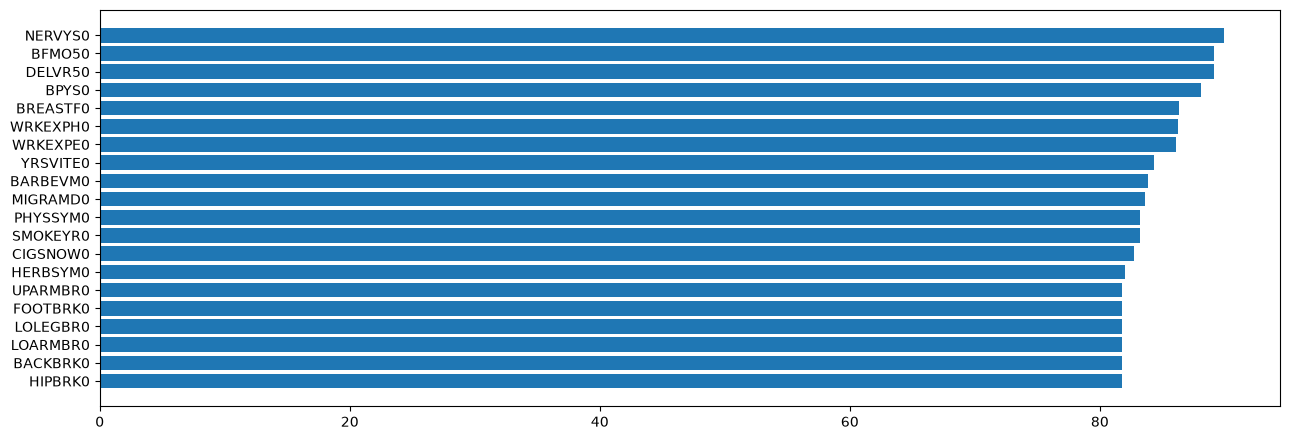

In [72]:
plt.figure(figsize=(13,4.5))
plt.barh(null.index[:20][::-1], null.values[:20][::-1])
plt.tight_layout()
plt.show()

In [75]:
df["STATUS0"].value_counts()
df["STATUS0"].isna().sum()

np.int64(42)